# Volatility Range Momentum

- Reproducing the findings from the paper - https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4824172&__cf_chl_f_tk=gGmUEcgnsyG883cHFwJJFxIrTKjeqviMOrPuhgSKFgQ-1782999913-1.0.1.1-pAgCnlxhuL2Sk_itXLzk5F_UYsX0NV31L1.1bpB4XDc

- Uses a rolling window close-close estimator on min. data.
- Volatility measure upto T minutes since start of day in the N lookback days.
- Constructs upper and lower bounds based on avg. volatility
- Triggers buy / sell signal based
- No overnight risk, positions closed at end of day.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
from core.strategy.vrm import load_noise_area
from tqdm import tqdm

In [2]:
volatility_multiplier = 1
lookback_days = 20

In [ ]:
df = pd.read_parquet("../../data/qqq_mins.parquet")
df.sort_index(inplace=True)
df["iterator"] = df.index.floor("24h")

In [4]:
df['close'] = df['close'].astype(float)
df['low'] =  df['low'].astype(float)
df['open'] = df['low'].astype(float)
df['high'] = df['high'].astype(float)
df['volume'] = df['volume'].astype(float)

In [5]:
df, latest_avg = load_noise_area(df, lookback_days=lookback_days, volatility_multiplier=volatility_multiplier, stoploss_multiplier=3)
df.dropna(inplace=True)

In [8]:
# Backtest
positions = pd.DataFrame()
for date in tqdm(df['date'].unique()):
    # if date <= datetime.datetime(2024,1,1).date():
    #     continue
    tmp = df[df.index.date == date]
    tmp = tmp.resample('30min').agg(close=('close','last'), vwap=('vwap', 'last'), upper_bound=('upper_bound', 'last'), lower_bound=('lower_bound', 'last'))

    tmp = tmp.shift(1).fillna(0)
    idxs = tmp.index
    eod = datetime.datetime(tmp.index[0].year, tmp.index[0].month, tmp.index[0].day, 16, 0, 0)
    cur_pos = 0


    for i in range(len(idxs)):
        if cur_pos == 0:
            if tmp.loc[idxs[i], 'close'] > tmp.loc[idxs[i], 'upper_bound']:
                cur_pos = 1
                df.loc[idxs[i]:eod, 'position'] = cur_pos
                continue
            if tmp.loc[idxs[i], 'close'] < tmp.loc[idxs[i], 'lower_bound']:
                cur_pos = -1
                df.loc[idxs[i]:eod, 'position'] = cur_pos
                continue
        elif cur_pos == 1:
            if (tmp.loc[idxs[i], 'close'] < tmp.loc[idxs[i], 'vwap']) or (tmp.loc[idxs[i], 'close'] < tmp.loc[idxs[i], 'upper_bound']):
                cur_pos = 0
                df.loc[idxs[i]:eod, 'position'] = cur_pos
                continue
        elif cur_pos == -1:
            if (tmp.loc[idxs[i], 'close'] > tmp.loc[idxs[i], 'vwap']) or (tmp.loc[idxs[i], 'close'] > tmp.loc[idxs[i], 'lower_bound']):
                cur_pos = 0
                df.loc[idxs[i]:eod, 'position'] = cur_pos
                continue


df['trade_open'] = 0
df['trade_close'] = 0
df['position'].fillna(0, inplace=True)
df.loc[(df['position'].abs() == 1) & (df['position'].shift().fillna(0) ==  0), 'trade_open'] += 1
df.loc[(df['position'].abs() == 1) & (df['position'].shift(-1).fillna(0) == 0), 'trade_close'] += 1

100%|██████████| 1583/1583 [04:34<00:00,  5.77it/s]


,Return Space
Total Returns,87.434652
Annualized Volatility,0.088765
Annualized Return,0.138246
Sharpe,1.557437
Max Gain/day,0.082347
Max Loss/day,-0.038546


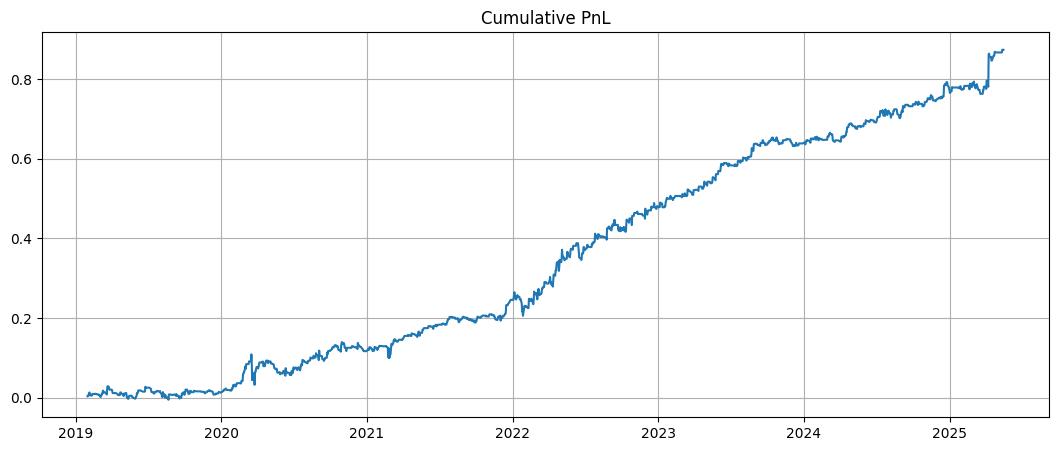

In [10]:
pnl = (df['position'] * df['close'].pct_change())
pnl = pnl.groupby(pnl.index.date).sum()
pnl.cumsum().plot(title="Cumulative PnL", figsize=(13, 5))
plt.grid()

pnl_stats = pd.DataFrame().from_dict(
    {
        "Total Returns": pnl.cumsum()[-1] * 100,
        "Annualized Volatility": pnl.std() * np.sqrt(250),
        "Annualized Return": (pnl.cumsum()[-1] * np.sqrt(250)/100),
        "Sharpe": (pnl.cumsum()[-1] * np.sqrt(250)/100)/(pnl.std() * np.sqrt(250)),
        "Max Gain/day": pnl.max(),
        "Max Loss/day": pnl.min()
    },
    orient="index",
    columns=["Return Space"]
)
pnl_stats

In [11]:
# Position Sizing based on AUM
df['qty'] = 0
df['strat_ret'] = 0

starting_cash = 10000
last_cash = 10000
leverage = 3
commissions = 0.35 # USD 0.35 minimum per trade // IBKR Pro - tiered pricing
volatility_target = 0.02 # 2% volatility
slippage = 0.02 # USD 2 cents

gross_cash = {}
net_cash = {}
total_comms = {}
daily_notional = {}

for cur_date in tqdm(sorted(df['date'].unique())):
    # if cur_date < datetime.datetime(2024,1,1).date():
    #     continue

    open_idx = df[(df['date'] == cur_date) & (df['trade_open'] == 1)].index
    close_idx = df[(df['date'] == cur_date) & (df['trade_close'] == 1)].index
    
    cur_qty = 0
    traded_notional = 0

    df['strat_ret'] = 0
    for i in range(len(open_idx)):
        traded_notional = (min(10000, last_cash) * min(leverage, volatility_target/df.loc[open_idx[i], 'sigma']))
        # traded_notional = last_cash * (volatility_target/df.loc[open_idx[i], 'sigma'])
        # traded_notional = last_cash * (leverage)
        cur_qty = traded_notional/df.loc[open_idx[i], 'close']

        df.loc[open_idx[i]:close_idx[i], 'qty'] = cur_qty
        df.loc[open_idx[i]:close_idx[i], 'strat_ret'] = df.loc[open_idx[i]:close_idx[i], 'close'].pct_change()
        df.loc[open_idx[i], 'strat_ret'] = (df.loc[open_idx[i]]['close'] / df.loc[open_idx[i]]['open']) - 1

        # slippage 
        df.loc[open_idx[i], 'strat_ret'] = df.loc[open_idx[i]]['strat_ret'] - ((slippage/df.loc[open_idx[i]]['open']) * df.loc[open_idx[i]]['position'])
        df.loc[close_idx[i], 'strat_ret'] = df.loc[close_idx[i]]['strat_ret'] - (slippage/df.loc[close_idx[i]]['close'] * df.loc[open_idx[i]]['position'])
    
    daily_notional[cur_date] = traded_notional
    
    cur_ret = (df[df['date'] == cur_date]['strat_ret'] * df[df['date'] == cur_date]['position']).cumsum()

    cur_comms = df[df['date'] == cur_date]['trade_open'] + df[df['date'] == cur_date]['trade_close']
    cur_comms = max(commissions, min((0.01 * traded_notional), (cur_qty * 0.0035))) * cur_comms.sum()

    starting_cash = starting_cash + (cur_ret[-1] * traded_notional)
    last_cash = last_cash + (cur_ret[-1] * traded_notional) - cur_comms

    gross_cash[cur_date] = starting_cash
    net_cash[cur_date] = last_cash
    total_comms[cur_date] = cur_comms


net_cash = pd.DataFrame().from_dict(net_cash, orient='index', columns=['net_cash'])
gross_cash = pd.DataFrame().from_dict(gross_cash, orient='index', columns=['gross_cash'])
total_comms = pd.DataFrame().from_dict(total_comms, orient='index', columns=['commissions'])
daily_notional = pd.DataFrame().from_dict(daily_notional, orient='index', columns=['daily_notional'])

100%|██████████| 1583/1583 [07:47<00:00,  3.38it/s]


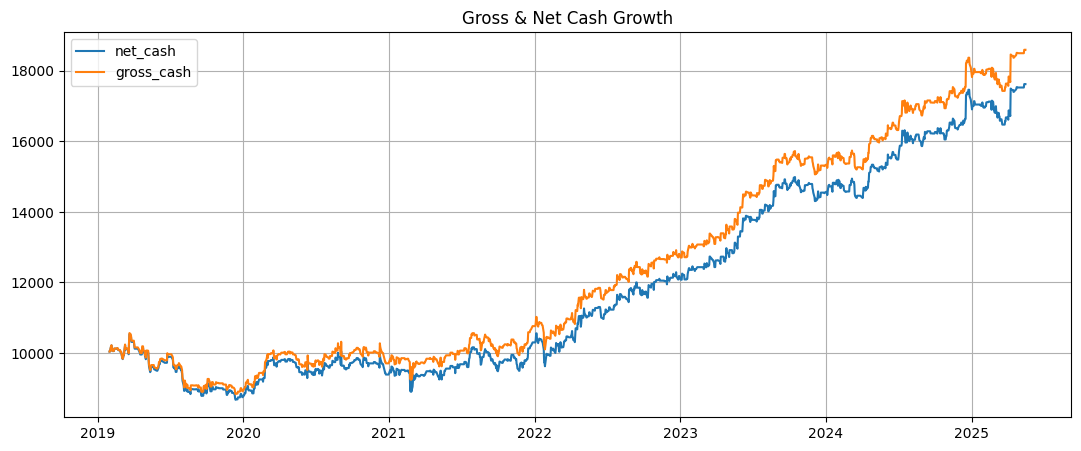

In [12]:
pd.concat([net_cash, gross_cash], axis=1).plot(title="Gross & Net Cash Growth", figsize=(13, 5))
plt.grid()

<Axes: >

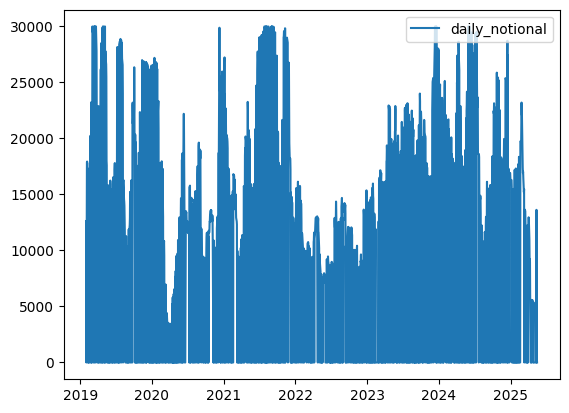

In [13]:
daily_notional.plot()

In [14]:
cash_pnl = net_cash.pct_change()['net_cash']
cash_pnl_stats = pd.DataFrame().from_dict(
    {
        "Total Returns": cash_pnl.cumsum().iloc[-1] * 100,
        "Annualized Volatility": cash_pnl.std() * np.sqrt(250),
        "Annualized Return": (cash_pnl.cumsum().iloc[-1] * np.sqrt(250)/100),
        "Sharpe": (cash_pnl.cumsum().iloc[-1] * np.sqrt(250)/100)/(cash_pnl.std() * np.sqrt(250)),
        "Max Gain/day": cash_pnl.max(),
        "Max Loss/day": cash_pnl.min()
    },
    orient="index",
    columns=["Return Space"]
)
cash_pnl_stats

,Return Space
Total Returns,60.553209
Annualized Volatility,0.116165
Annualized Return,0.095743
Sharpe,0.824201
Max Gain/day,0.046627
Max Loss/day,-0.044224


,stats
Pct. of profitable days,0.318383
Pct. of loss days,0.258370
Pct. of neutral days,0.422615
Avg. loss,-0.005775
Avg. Gain,0.008597


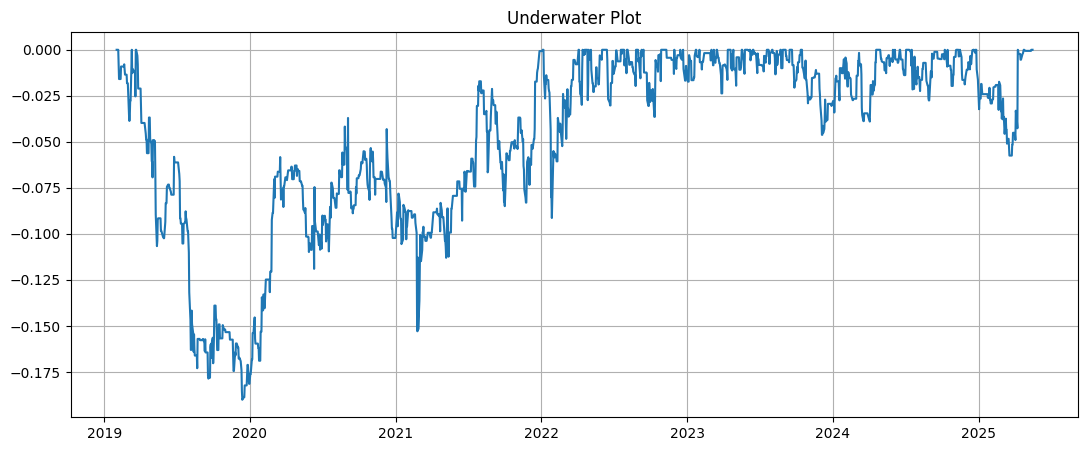

In [15]:
# Underwater stats
uw_stats = pd.DataFrame().from_dict(
        {
        "Pct. of profitable days": (net_cash.pct_change() < 0).sum()[0]/len(net_cash),
        "Pct. of loss days": (net_cash.pct_change() > 0).sum()[0]/len(net_cash),
        "Pct. of neutral days": (net_cash.pct_change() == 0).sum()[0]/len(net_cash),
        "Avg. loss": net_cash.pct_change()[net_cash.pct_change() < 0].mean()[0],
        "Avg. Gain": net_cash.pct_change()[net_cash.pct_change() > 0].mean()[0]
    },
    orient='index',
    columns=['stats']
)

uw = net_cash.copy()
uw['ret'] = net_cash.pct_change().cumsum()
uw['max'] = uw['ret'].cummax()
(uw['ret'] - uw['max']).plot(title="Underwater Plot", figsize=(13, 5))
plt.grid()

uw_stats

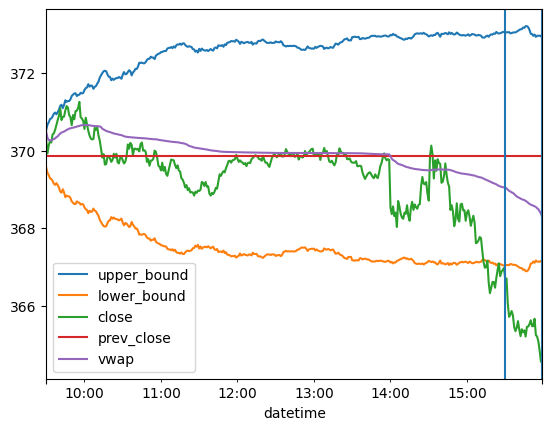

In [16]:
# check entry and exit conditions again, should be either the bound OR vwap to hit stop loss - think about it?

test_datetime = datetime.datetime(2023,9,20,15,30,0)
test_date = test_datetime.date()
test_time = test_datetime.time()
df[df['date'] == test_date][['upper_bound', 'lower_bound', 'close', 'prev_close', 'vwap']].plot()
for d in df[(df['date'] == test_date) & ((df['trade_open'] == 1) | (df['trade_close'] == 1))].index:
    plt.axvline(d)
# plt.axvline(test_datetime)